# Olist E-commerce Operational Performance Analysis
*Project Scope: 2017 - 2018 Data Analysis*

*Key Metric: Order Volume vs. Cancellation Rate (%)*

---

## 1. Research Context & Discovery
Through exploratory analysis of Olist’s 2017-2018 datasets, I identified a critical trend worth investigating: the correlation between rapid business scaling and operational stability.

* **The Discovery:** Initial data inspection revealed a 10x growth in volume. I wanted to verify if this expansion triggered an increase in the cancellation rate.

* **Analytical Focus:** I developed a Dual-Axis Dashboard to confirm whether the logistics infrastructure remained resilient during peak periods.

## 2. Key Insights
* **Demonstrated Scalability:** Despite a 10x increase in total order volume, the Cancellation Rate remained stable. Olist's operations are highly scalable.
* **Resilience Under Pressure:** During the Nov 2017 "Black Friday" peak, the Cancellation Rate (%) remained flat despite record-high volumes, proving logistics resilience.
* **Operational Maturity:** Comparing early 2018 to 2017, cancellation rates showed a downward trend at similar volumes, suggesting process optimization.

## 3. Next Steps (Root Cause Analysis)
To further optimize customer experience, I will perform:
* **Category Attribution:** Identify if high cancellation rates are concentrated in specific categories.
* **Logistics Correlation:** Verify if "Estimated Delivery Time" delays drive "Customer Regret."
* **Geographic Analysis:** Identify underperforming regional logistics partners by state.

In [62]:
import os

os.environ['KAGGLE_USERNAME'] = "changyingkang"
os.environ['KAGGLE_KEY'] = "KGAT_46d5f875a7ae806b7a866f2ea340ab33"

!kaggle datasets list -s "brazilian-ecommerce"

ref                                                      title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
olistbr/brazilian-ecommerce                              Brazilian E-Commerce Public Dataset by Olist     44717580  2021-10-01 19:08:27.970000         527698       4173                1  
iris111/brazilianecommerce                               brazilian-ecommerce                              44717580  2022-12-09 12:17:57.960000            100          1       0.23529412  
deremmy/brazilian-e-commerce-dashboardpower-bi           Brazilian E-Commerce Dashboard(POWER BI)          7161290  2023-12-27 23:56:20.233000            221          2        0.8235294  
patrickgomes/ecommerce1-dataset                          Eco

# 1. Data Loading & Integrity Check
In this section, I imported the Olist datasets and performed initial sanity checks to understand the schema and data types.



In [63]:
import pandas as pd
df_orders = pd.read_csv('/content/olist_orders_dataset.csv')
# Observe df: columns and dtype
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


# 2. Data Cleaning and exploring
Standardized time-series data and filtered for the 2017-2018 period.

In [64]:
# Reset date column dtype: object > datetime
df_orders['order_purchase_timestamp']=pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at']=pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_carrier_date']=pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date']=pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date']=pd.to_datetime(df_orders['order_estimated_delivery_date'])


In [65]:
# Confirm the datase timerange
print('Earlist purchase timestamp: ' , df_orders['order_purchase_timestamp'].min())
print('Latest purchase timestamp: ' , df_orders['order_purchase_timestamp'].max())

Earlist purchase timestamp:  2016-09-04 21:15:19
Latest purchase timestamp:  2018-10-17 17:30:18


In [66]:
# Order amount by month
monthly_order=df_orders.groupby(df_orders['order_purchase_timestamp'].dt.month)['order_id'].count().reset_index()
monthly_order=monthly_order.rename(columns={'order_purchase_timestamp':'month','order_id':'order_amount'})
monthly_order

,month,order_amount
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


# 3. Exploratory Visualization (The Discovery Process)
*Note: This section records my initial attempts to visualize the data.*

I explored various ways to represent order statuses. These initial charts helped me identify that absolute volumes and rates are on different scales, leading to the need for a more advanced visualization.

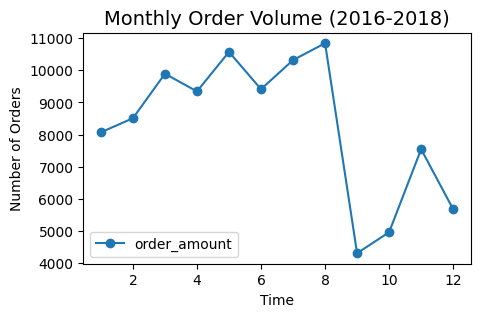

In [67]:
# Linechart for monthly order amount
import matplotlib.pyplot as plt
monthly_order.plot(x='month', y='order_amount', kind='line', marker='o', figsize=(5, 3))
plt.title('Monthly Order Volume (2016-2018)', fontsize=14)
plt.xlabel('Time', fontsize=10)
plt.ylabel('Number of Orders', fontsize=10)
plt.grid(False) #gridlines

In [68]:
# Order status by month using pivot
# print('order_status_list:',df_orders['order_status'].unique())
pivot_result=df_orders.pivot_table(index=df_orders['order_purchase_timestamp'].dt.to_period('M'),
                                   columns='order_status',
                                   values='order_id',
                                   aggfunc='count').fillna(0)
pivot_result = pivot_result.astype(int)
pivot_result = pivot_result.reset_index()
pivot_result = pivot_result.rename(columns={'order_purchase_timestamp': 'Month'})
pivot_result['Month'] = pivot_result['Month'].astype(str)

#pivot_result=pivot_result.astype(int)
new_column_order=['Month','delivered','shipped','processing','invoiced','created','approved','canceled','unavailable']
pivot_result=pivot_result[new_column_order]
pivot_result

order_status,Month,delivered,shipped,processing,invoiced,created,approved,canceled,unavailable
0,2016-09,1,1,0,0,0,0,2,0
1,2016-10,265,8,2,18,0,0,24,7
2,2016-12,1,0,0,0,0,0,0,0
3,2017-01,750,16,9,12,0,0,3,10
4,2017-02,1653,21,32,11,0,1,17,45
5,2017-03,2546,45,23,3,0,0,33,32
6,2017-04,2303,49,10,14,0,1,18,9
7,2017-05,3546,55,23,16,0,0,29,31
8,2017-06,3135,47,12,11,0,0,16,24
9,2017-07,3872,56,11,7,0,0,28,52


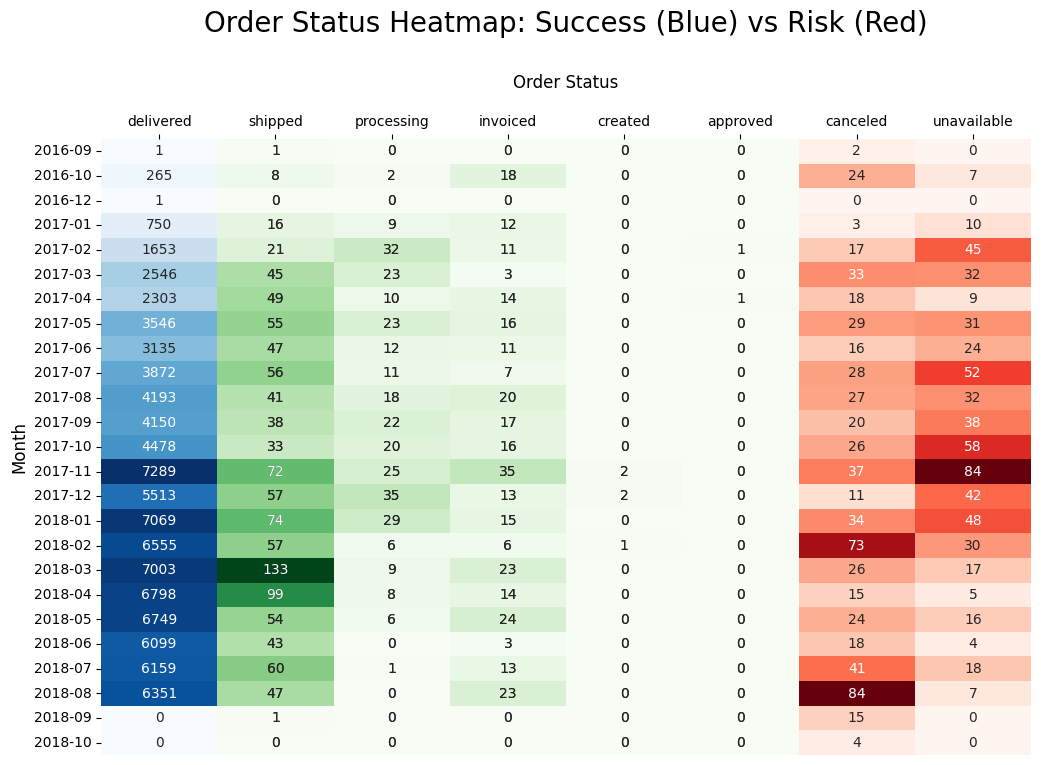

In [69]:
# orders by status monthly count heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plot_data = pivot_result.set_index('Month')
fig, ax = plt.subplots(figsize=(12, 8))

blue_cols = ['delivered',]
green_cols = ['processing','invoiced','created','shipped','approved']
red_cols = [c for c in plot_data.columns if c not in blue_cols+green_cols]


# Blue data
blue_data = plot_data.copy()
blue_data[red_cols] = np.nan
sns.heatmap(blue_data, annot=True, fmt='.0f', cmap='Blues', cbar=False, ax=ax)

# Green data
green_data = plot_data.copy()
green_data[blue_cols + red_cols] = np.nan
sns.heatmap(green_data, annot=True, fmt='.0f', cmap='Greens', cbar=False, ax=ax)

# Red data
red_data = plot_data.copy()
red_data[blue_cols + green_cols] = np.nan
sns.heatmap(red_data, annot=True, fmt='.0f', cmap='Reds', cbar=False, ax=ax)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=0)

plt.title('Order Status Heatmap: Success (Blue) vs Risk (Red)', fontsize=20, pad=30)
plt.xlabel('Order Status', fontsize=12, labelpad=20)
plt.ylabel('Month', fontsize=12)
plt.yticks(rotation=0)

plt.show()

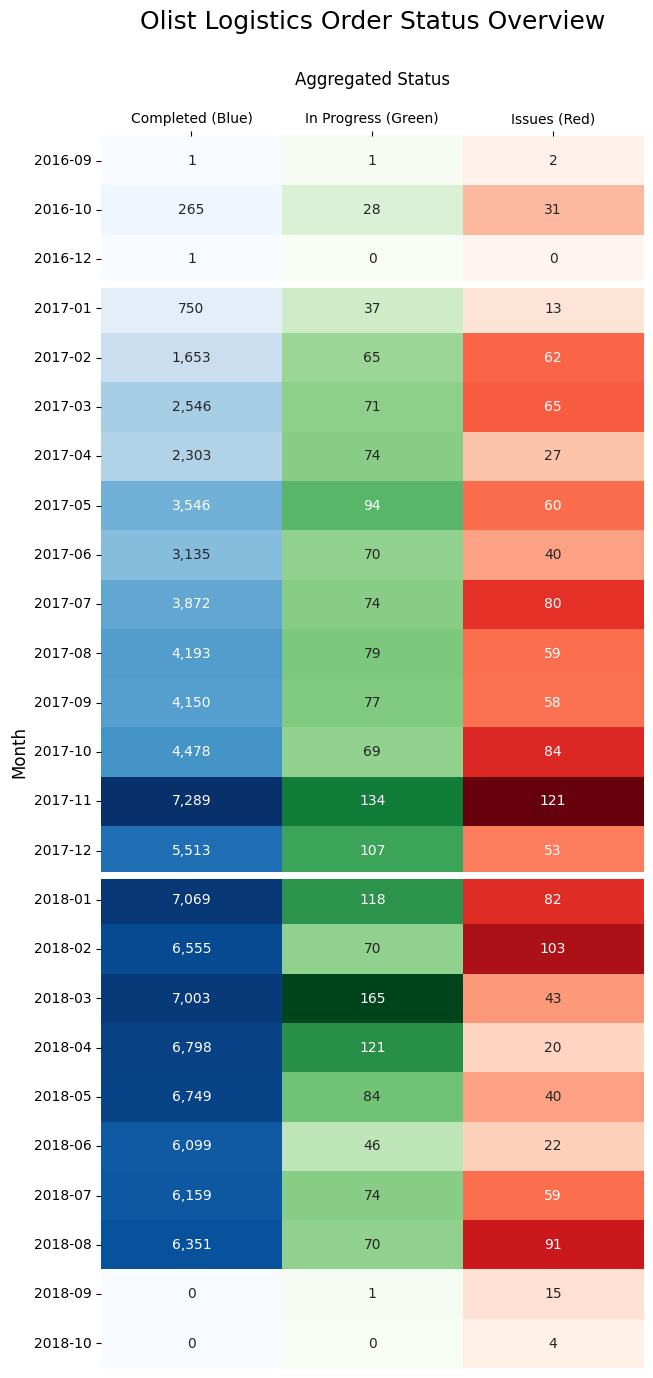

In [79]:
# Aggregated Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## data
plot_data = pivot_result.set_index('Month').copy()

# Completed (Blue)
plot_data['Completed (Blue)'] = plot_data['delivered']
# In Progress (Green)
green_cols = ['processing', 'invoiced', 'created', 'shipped', 'approved']
plot_data['In Progress (Green)'] = plot_data[green_cols].sum(axis=1)
#'Issues (Red)'
exclude_cols = ['delivered', 'Completed (Blue)', 'In Progress (Green)'] + green_cols
red_cols = [c for c in plot_data.columns if c not in exclude_cols]
plot_data['Issues (Red)'] = plot_data[red_cols].sum(axis=1)

final_plot = plot_data[['Completed (Blue)', 'In Progress (Green)', 'Issues (Red)']]

## Draw heatmap
fig, ax = plt.subplots(figsize=(7, 16))

#year seperator
ax.axhline(y=3, color='white', linewidth=5)
ax.axhline(y=15, color='white', linewidth=5)

# Completed (Blue)
blue_data = final_plot.copy()
blue_data[['In Progress (Green)', 'Issues (Red)']] = np.nan
sns.heatmap(blue_data, annot=True, fmt=',.0f', cmap='Blues', cbar=False, ax=ax)

# In Progress (Green)
green_data = final_plot.copy()
green_data[['Completed (Blue)', 'Issues (Red)']] = np.nan
sns.heatmap(green_data, annot=True, fmt=',.0f', cmap='Greens', cbar=False, ax=ax)

#'Issues (Red)'
red_data = final_plot.copy()
red_data[['Completed (Blue)', 'In Progress (Green)']] = np.nan
sns.heatmap(red_data, annot=True, fmt=',.0f', cmap='Reds', cbar=False, ax=ax)

# labels & title
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=0)

plt.title('Olist Logistics Order Status Overview', fontsize=18, pad=30)
plt.xlabel('Aggregated Status', fontsize=12, labelpad=20)
plt.ylabel('Month', fontsize=12)
plt.yticks(rotation=0)

plt.show()

In [80]:
#status in percentage
row_totals = final_plot.sum(axis=1)
rate_plot = round(final_plot.divide(row_totals, axis=0) * 100,2)
print(rate_plot.head())

order_status  Completed (Blue)  In Progress (Green)  Issues (Red)
Month                                                            
2016-09                  25.00                25.00         50.00
2016-10                  81.79                 8.64          9.57
2016-12                 100.00                 0.00          0.00
2017-01                  93.75                 4.62          1.62
2017-02                  92.87                 3.65          3.48


# 4. Final Operational Dashboard
This is the final, refined visualization used for management reporting. It correlates order volume with cancellation rates to provide a comprehensive view of operational scalability.

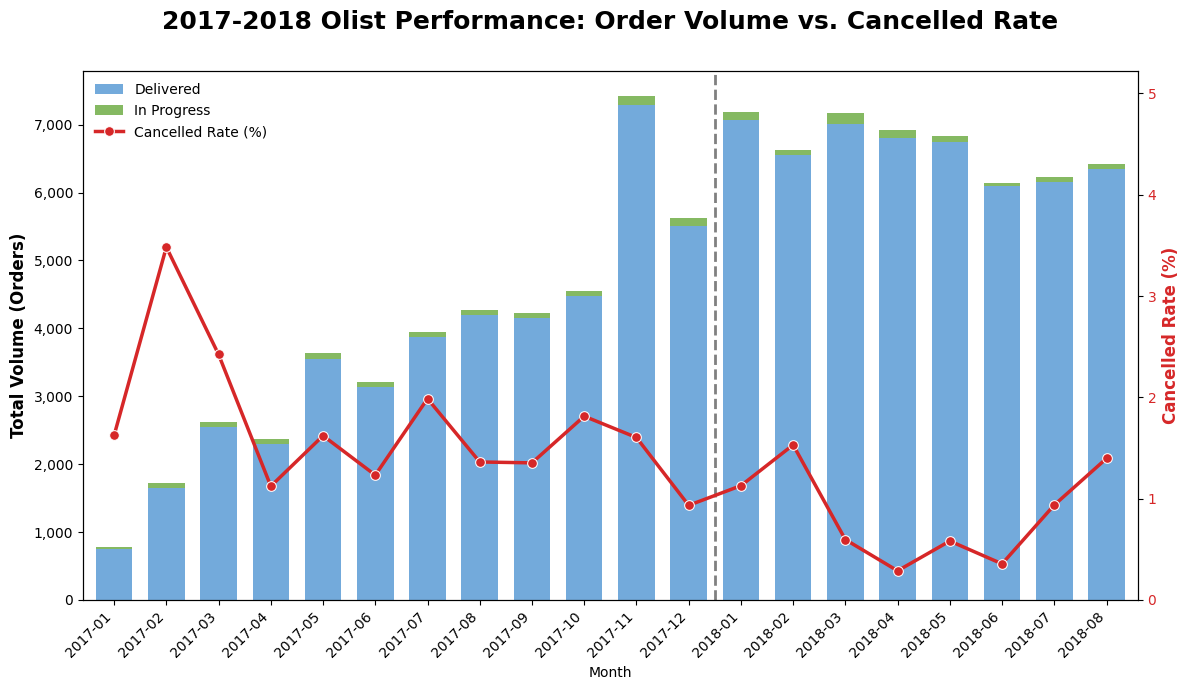

In [88]:
# Dual-Axis Combo Chart: completed orders amount vs cancellation rate by month


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# dataset
plot_data = final_plot.copy()
plot_data.index = plot_data.index.astype(str)

# setting duration: 2017 all + 2018/01-08
plot_data = plot_data[plot_data.index.str.startswith(('2017', '2018'))].sort_index()
plot_data = plot_data[plot_data.index <= '2018-08']

# cancellation rate
row_totals = plot_data.sum(axis=1)
plot_data['Cancelled Rate (%)'] = (plot_data.iloc[:, -1] / row_totals) * 100

# rename columns
plot_data = plot_data.rename(columns={
    plot_data.columns[0]: 'Delivered (Blue)',
    plot_data.columns[1]: 'In Progress (Green)'
})

# basic setting
fig, ax1 = plt.subplots(figsize=(12, 7))

# left axis (delivered+inprogress bar chart)
bar_cols = ['Delivered (Blue)', 'In Progress (Green)']
plot_data[bar_cols].plot(kind='bar', stacked=True, color=['#5b9bd5', '#70ad47'],
                         ax=ax1, width=0.7, alpha=0.85)

ax1.set_ylabel('Total Volume (Orders)', fontsize=12, fontweight='bold')
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45, ha='right')

# right axis (cancellation rate line chart)
ax2 = ax1.twinx()
sns.lineplot(data=plot_data, x=plot_data.index, y='Cancelled Rate (%)', color='#d62728',
             linewidth=2.5, marker='o', markersize=7, markeredgecolor='white',
             ax=ax2, label='Cancelled Rate (%)')

ax2.set_ylabel('Cancelled Rate (%)', fontsize=12, color='#d62728', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, plot_data['Cancelled Rate (%)'].max() * 1.5)

# title and year seperator
sep_idx = len(plot_data[plot_data.index.str.startswith('2017')]) - 0.5
ax1.axvline(x=sep_idx, color='grey', linewidth=2, linestyle='--')

plt.title('2017-2018 Olist Performance: Order Volume vs. Cancelled Rate',
          fontsize=18, pad=30, fontweight='bold')

# labels setting
if ax2.get_legend():
    ax2.get_legend().remove()

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, ['Delivered', 'In Progress', 'Cancelled Rate (%)'],
           loc='upper left', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig('dashboard.png', dpi=300)